In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Iris.csv to Iris.csv


In [ ]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import DBSCAN

In [ ]:
# Column names as per UCI IRIS dataset
columns = [
"sepal_length",
"sepal_width",
"petal_length",
"petal_width",
"species"
]

In [ ]:
data = pd.read_csv("Iris.csv")

In [ ]:
df = data.drop("Species", axis=1)

In [ ]:
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0   1            5.1           3.5            1.4           0.2
1   2            4.9           3.0            1.4           0.2
2   3            4.7           3.2            1.3           0.2
3   4            4.6           3.1            1.5           0.2
4   5            5.0           3.6            1.4           0.2


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster']= kmeans_labels

In [ ]:
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
print("\nK-Means Silhouette Score:", kmeans_silhouette)


K-Means Silhouette Score: 0.452949780355554


In [ ]:
hierarchical = AgglomerativeClustering(n_clusters=3)
hierarchical_labels = hierarchical.fit_predict(X_scaled)
df['Hierarchical_Cluster']= hierarchical_labels

In [ ]:
hierarchical_silhouette = silhouette_score(X_scaled, hierarchical_labels)
print("Hierarchical Clustering Silhouette Score:", hierarchical_silhouette)

Hierarchical Clustering Silhouette Score: 0.45183200660097467


In [ ]:
plt.figure(figsize=(10,5))
linked = linkage(X_scaled, method='ward')

<Figure size 1000x500 with 0 Axes>

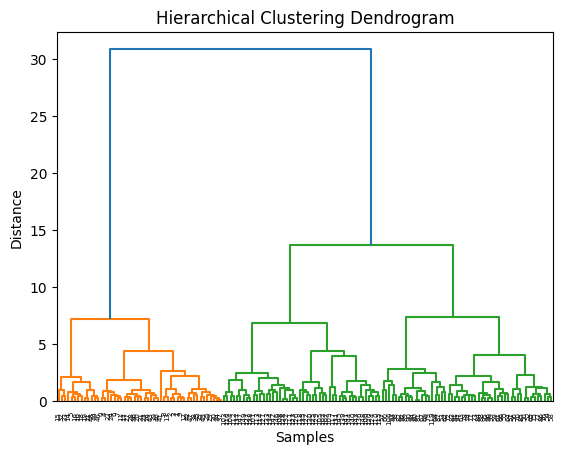

In [ ]:
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [ ]:
plt.figure(figsize=(12,5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

Text(0, 0.5, 'Feature 2')

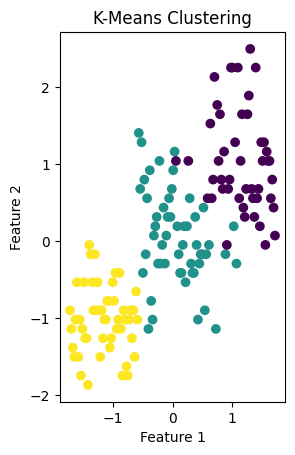

In [ ]:
plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_labels, cmap='viridis')
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

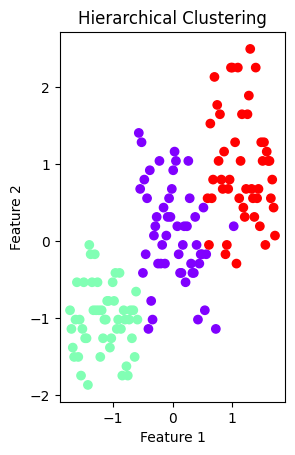

In [ ]:
plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=hierarchical_labels, cmap='rainbow')
plt.title("Hierarchical Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
agglo = AgglomerativeClustering(n_clusters=3)
agglo_labels = agglo.fit_predict(X_scaled)

print("Agglomerative Silhouette Score:",
      silhouette_score(X_scaled, agglo_labels))

Agglomerative Silhouette Score: 0.45183200660097467


In [ ]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# DBSCAN may include noise (-1), so check before silhouette
if len(set(dbscan_labels)) > 1:
    print("DBSCAN Silhouette Score:",
          silhouette_score(X_scaled, dbscan_labels))
else:
    print("DBSCAN could not form valid clusters")

DBSCAN Silhouette Score: 0.4372558175232889


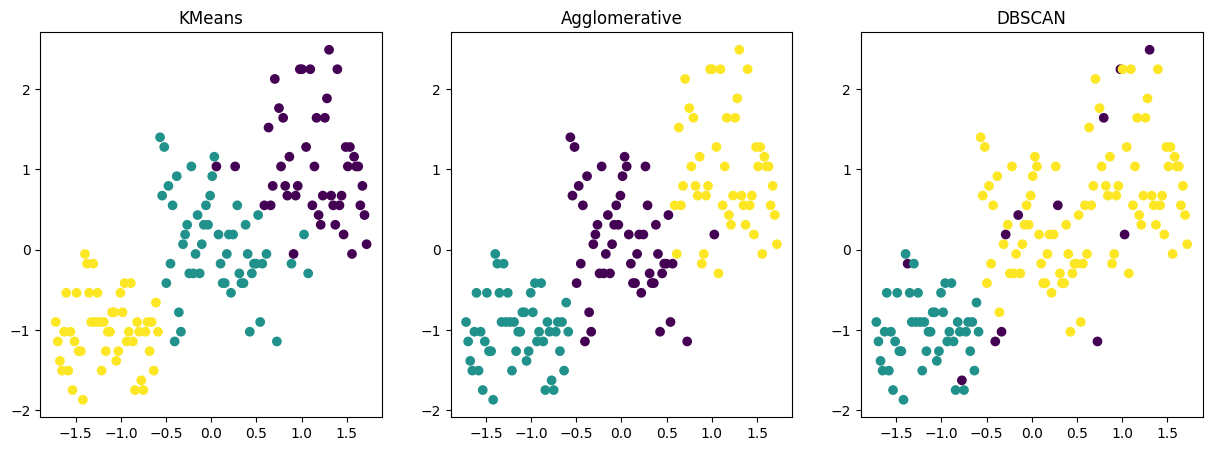

In [ ]:
plt.figure(figsize=(15,5))

# KMeans
plt.subplot(1,3,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_labels)
plt.title("KMeans")

# Agglomerative
plt.subplot(1,3,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=agglo_labels)
plt.title("Agglomerative")

# DBSCAN
plt.subplot(1,3,3)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=dbscan_labels)
plt.title("DBSCAN")

plt.show()